In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from utils import (
    load_model, save_model, evaluate_model_comprehensive,
    plot_reliability_curve, decompose_brier_score, print_metrics_report
)
from calibration import (
    calibrate_model_to_target_pd, PlattScaling, IsotonicCalibration,
    BetaCalibration, CalibrationInTheLarge, create_calibrated_model_pipeline
)

import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load Data and Models

In [2]:
# Load test data
test = pd.read_csv('../data/test.csv')
X_test = test.drop(columns=['default'])
y_test = test['default']

print(f"Test set size: {len(X_test)}")
print(f"Test set default rate: {y_test.mean():.4f} ({y_test.mean()*100:.2f}%)")

# Split test set into calibration and validation
X_cal, X_val, y_cal, y_val = train_test_split(
    X_test, y_test, test_size=0.5, random_state=2137, stratify=y_test
)

print(f"\nCalibration set size: {len(X_cal)}")
print(f"Validation set size: {len(X_val)}")

Test set size: 900
Test set default rate: 0.0589 (5.89%)

Calibration set size: 450
Validation set size: 450


In [3]:
# Load tuned models
lr_model = load_model('../models/tuned_logistic_regression.pkl')
rf_model = load_model('../models/tuned_random_forest.pkl')

print("Models loaded successfully!")
print(f"Logistic Regression: {type(lr_model)}")
print(f"Random Forest: {type(rf_model)}")

Models loaded successfully!
Logistic Regression: <class 'sklearn.pipeline.Pipeline'>
Random Forest: <class 'sklearn.pipeline.Pipeline'>


## 2. Pre-Calibration Evaluation

In [4]:
# Evaluate LR before calibration
print("\n" + "="*80)
print("LOGISTIC REGRESSION - PRE-CALIBRATION")
print("="*80)

lr_metrics_pre = evaluate_model_comprehensive(lr_model, X_val, y_val)
print_metrics_report(lr_metrics_pre, "Logistic Regression - Pre-Calibration")

# Get predictions for calibration analysis
lr_proba_pre = lr_model.predict_proba(X_val)[:, 1]
print(f"\nMean predicted PD: {np.mean(lr_proba_pre):.4f} ({np.mean(lr_proba_pre)*100:.2f}%)")
print(f"Target PD: 0.0400 (4.00%)")
print(f"Gap: {(np.mean(lr_proba_pre) - 0.04)*100:.2f} percentage points")


LOGISTIC REGRESSION - PRE-CALIBRATION
           Logistic Regression - Pre-Calibration            

Probabilistic Metrics:
------------------------------------------------------------
  roc_auc                       : 0.7531
  pr_auc                        : 0.2017
  brier_score                   : 0.2262
  log_loss                      : 0.6442
  ks_statistic                  : 0.4869

Classification Metrics:
------------------------------------------------------------
  accuracy                      : 0.6422
  precision                     : 0.1186
  recall                        : 0.8077
  f1_score                      : 0.2069
  specificity                   : 0.6321

Calibration Metrics:
------------------------------------------------------------
  ece                           : 0.4023
  mean_predicted_probability    : 0.4601
  mean_actual_rate              : 0.0578

Confusion Matrix:
------------------------------------------------------------
  True Positives (TP):  21
  True

In [5]:
# Evaluate RF before calibration
print("\n" + "="*80)
print("RANDOM FOREST - PRE-CALIBRATION")
print("="*80)

rf_metrics_pre = evaluate_model_comprehensive(rf_model, X_val, y_val)
print_metrics_report(rf_metrics_pre, "Random Forest - Pre-Calibration")

# Get predictions
rf_proba_pre = rf_model.predict_proba(X_val)[:, 1]
print(f"\nMean predicted PD: {np.mean(rf_proba_pre):.4f} ({np.mean(rf_proba_pre)*100:.2f}%)")
print(f"Target PD: 0.0400 (4.00%)")
print(f"Gap: {(np.mean(rf_proba_pre) - 0.04)*100:.2f} percentage points")


RANDOM FOREST - PRE-CALIBRATION
              Random Forest - Pre-Calibration               

Probabilistic Metrics:
------------------------------------------------------------
  roc_auc                       : 0.7733
  pr_auc                        : 0.2482
  brier_score                   : 0.0497
  log_loss                      : 0.1927
  ks_statistic                  : 0.5131

Classification Metrics:
------------------------------------------------------------
  accuracy                      : 0.9444
  precision                     : 1.0000
  recall                        : 0.0385
  f1_score                      : 0.0741
  specificity                   : 1.0000

Calibration Metrics:
------------------------------------------------------------
  ece                           : 0.0153
  mean_predicted_probability    : 0.0599
  mean_actual_rate              : 0.0578

Confusion Matrix:
------------------------------------------------------------
  True Positives (TP):  1
  True Negati

## 3. Reliability Curves - Pre-Calibration

In [6]:
# Quick check of probability distributions
print("\n" + "="*80)
print("PROBABILITY DISTRIBUTION ANALYSIS")
print("="*80)

print("\nLogistic Regression probabilities:")
print(f"  Min: {lr_proba_pre.min():.6f}")
print(f"  Max: {lr_proba_pre.max():.6f}")
print(f"  Mean: {lr_proba_pre.mean():.6f}")
print(f"  Median: {np.median(lr_proba_pre):.6f}")
print(f"  Std: {lr_proba_pre.std():.6f}")

print("\nRandom Forest probabilities:")
print(f"  Min: {rf_proba_pre.min():.6f}")
print(f"  Max: {rf_proba_pre.max():.6f}")
print(f"  Mean: {rf_proba_pre.mean():.6f}")
print(f"  Median: {np.median(rf_proba_pre):.6f}")
print(f"  Std: {rf_proba_pre.std():.6f}")

# Check how many samples in extreme ranges
print(f"\nLR: Samples with p > 0.5: {np.sum(lr_proba_pre > 0.5)} ({np.sum(lr_proba_pre > 0.5)/len(lr_proba_pre)*100:.1f}%)")
print(f"RF: Samples with p > 0.5: {np.sum(rf_proba_pre > 0.5)} ({np.sum(rf_proba_pre > 0.5)/len(rf_proba_pre)*100:.1f}%)")
print(f"\nLR: Samples with p > 0.9: {np.sum(lr_proba_pre > 0.9)} ({np.sum(lr_proba_pre > 0.9)/len(lr_proba_pre)*100:.1f}%)")
print(f"RF: Samples with p > 0.9: {np.sum(rf_proba_pre > 0.9)} ({np.sum(rf_proba_pre > 0.9)/len(rf_proba_pre)*100:.1f}%)")


PROBABILITY DISTRIBUTION ANALYSIS

Logistic Regression probabilities:
  Min: 0.088506
  Max: 0.899570
  Mean: 0.460103
  Median: 0.461529
  Std: 0.160703

Random Forest probabilities:
  Min: 0.021256
  Max: 0.532339
  Mean: 0.059860
  Median: 0.046127
  Std: 0.053124

LR: Samples with p > 0.5: 177 (39.3%)
RF: Samples with p > 0.5: 1 (0.2%)

LR: Samples with p > 0.9: 0 (0.0%)
RF: Samples with p > 0.9: 0 (0.0%)


In [7]:
# DIAGNOSTIC: Check actual vs predicted default rates
print("\n" + "="*80)
print("⚠️  CALIBRATION DIAGNOSTIC")
print("="*80)

actual_default_rate = y_val.mean()
lr_predicted_rate = lr_proba_pre.mean()
rf_predicted_rate = rf_proba_pre.mean()

print(f"\n📊 Actual default rate in validation set: {actual_default_rate:.4f} ({actual_default_rate*100:.2f}%)")
print(f"\n📉 Logistic Regression:")
print(f"   Predicted mean PD: {lr_predicted_rate:.4f} ({lr_predicted_rate*100:.2f}%)")
print(f"   Overestimation: {lr_predicted_rate/actual_default_rate:.2f}x")
print(f"   Gap to 4% target: {(lr_predicted_rate - 0.04)*100:.2f} p.p.")
print(f"   ⚠️  WARNING: Model is SEVERELY UNCALIBRATED!")

print(f"\n🌲 Random Forest:")
print(f"   Predicted mean PD: {rf_predicted_rate:.4f} ({rf_predicted_rate*100:.2f}%)")
print(f"   Ratio to actual: {rf_predicted_rate/actual_default_rate:.2f}x")
print(f"   Gap to 4% target: {(rf_predicted_rate - 0.04)*100:.2f} p.p.")
print(f"   ✓ Relatively well calibrated (close to actual rate)")

print(f"\n💡 This is exactly why we need calibration!")
print(f"   LR needs MAJOR calibration shift: {lr_predicted_rate:.1%} → 4%")
print(f"   RF needs minor adjustment: {rf_predicted_rate:.1%} → 4%")


⚠️  CALIBRATION DIAGNOSTIC

📊 Actual default rate in validation set: 0.0578 (5.78%)

📉 Logistic Regression:
   Predicted mean PD: 0.4601 (46.01%)
   Overestimation: 7.96x
   Gap to 4% target: 42.01 p.p.
   ⚠️  WARNING: Model is SEVERELY UNCALIBRATED!

🌲 Random Forest:
   Predicted mean PD: 0.0599 (5.99%)
   Ratio to actual: 1.04x
   Gap to 4% target: 1.99 p.p.
   ✓ Relatively well calibrated (close to actual rate)

💡 This is exactly why we need calibration!
   LR needs MAJOR calibration shift: 46.0% → 4%
   RF needs minor adjustment: 6.0% → 4%


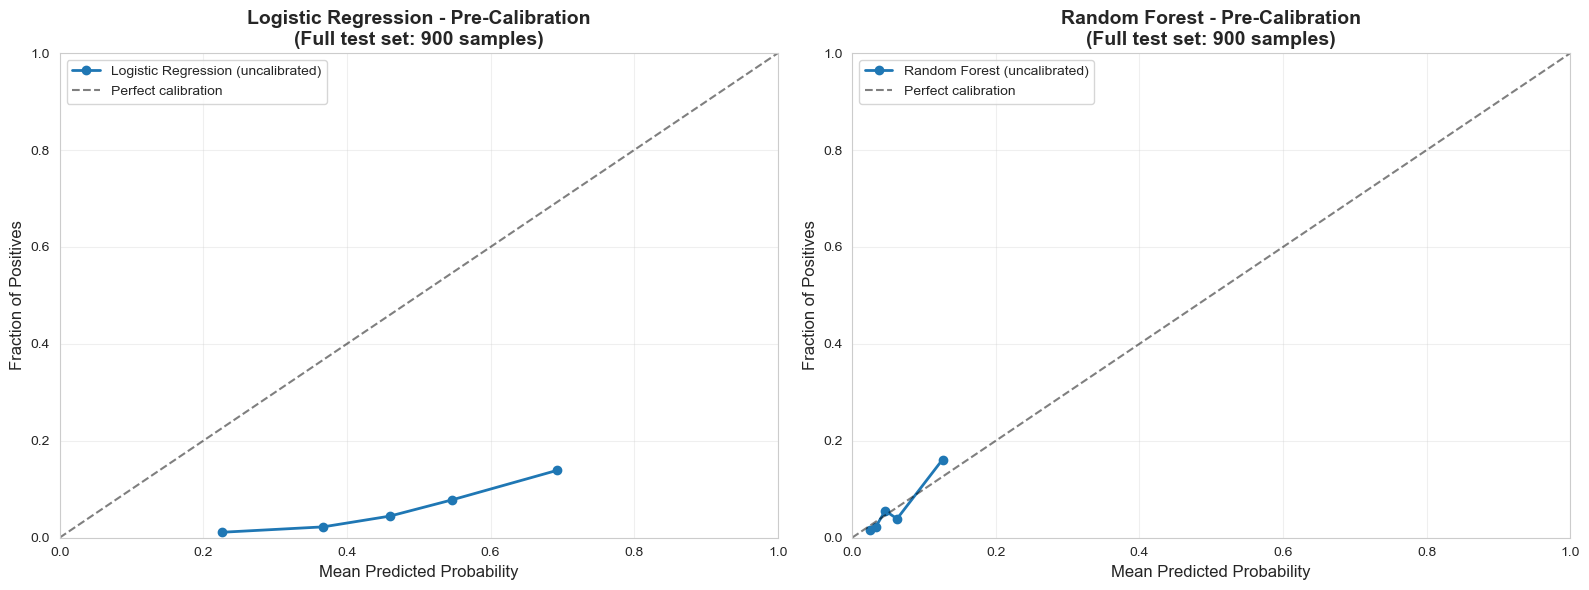


📊 Using full test set for more stable estimates:
   Total samples: 900
   Defaults: 53 (5.9%)
   Average per bin (n=5): ~180 samples, ~11 defaults


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Use FULL TEST SET for more stable reliability curves (900 samples instead of 450)
lr_proba_full = lr_model.predict_proba(X_test)[:, 1]
rf_proba_full = rf_model.predict_proba(X_test)[:, 1]

# LR reliability curve with quantile binning for stability
plot_reliability_curve(y_test, lr_proba_full, n_bins=5, ax=axes[0], 
                      label='Logistic Regression (uncalibrated)')
axes[0].set_title('Logistic Regression - Pre-Calibration\n(Full test set: 900 samples)', 
                 fontsize=14, fontweight='bold')

# RF reliability curve
plot_reliability_curve(y_test, rf_proba_full, n_bins=5, ax=axes[1], 
                      label='Random Forest (uncalibrated)')
axes[1].set_title('Random Forest - Pre-Calibration\n(Full test set: 900 samples)', 
                 fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n📊 Using full test set for more stable estimates:")
print(f"   Total samples: {len(X_test)}")
print(f"   Defaults: {y_test.sum()} ({y_test.mean()*100:.1f}%)")
print(f"   Average per bin (n=5): ~{len(X_test)/5:.0f} samples, ~{y_test.sum()/5:.0f} defaults")

## 4. Brier Score Decomposition - Pre-Calibration

In [9]:
# Decompose Brier score for both models
lr_brier_decomp = decompose_brier_score(y_val, lr_proba_pre)
rf_brier_decomp = decompose_brier_score(y_val, rf_proba_pre)

print("\n" + "="*80)
print("BRIER SCORE DECOMPOSITION - PRE-CALIBRATION")
print("="*80)
print("\nLogistic Regression:")
for key, value in lr_brier_decomp.items():
    print(f"  {key:20s}: {value:.6f}")

print("\nRandom Forest:")
for key, value in rf_brier_decomp.items():
    print(f"  {key:20s}: {value:.6f}")

print("\nNote: Brier = Reliability - Resolution + Uncertainty")
print("Lower Reliability (calibration error) is better")
print("Higher Resolution (discrimination) is better")


BRIER SCORE DECOMPOSITION - PRE-CALIBRATION

Logistic Regression:
  brier               : 0.226175
  reliability         : 0.176209
  resolution          : 0.004676
  uncertainty         : 0.054440

Random Forest:
  brier               : 0.049702
  reliability         : 0.001371
  resolution          : 0.005571
  uncertainty         : 0.054440

Note: Brier = Reliability - Resolution + Uncertainty
Lower Reliability (calibration error) is better
Higher Resolution (discrimination) is better


## 5. Calibrate Logistic Regression to 4% PD

In [10]:
# Test different calibration methods
calibration_methods = ['platt', 'isotonic', 'beta']
lr_calibration_results = {}

print("\n" + "="*80)
print("LOGISTIC REGRESSION - CALIBRATION TO 4% PD")
print("="*80)

for method in calibration_methods:
    print(f"\n{'='*40}")
    print(f"Method: {method.upper()}")
    print(f"{'='*40}")
    
    result = calibrate_model_to_target_pd(
        lr_model, X_cal, y_cal, X_val, 
        target_pd=0.04, method=method
    )
    
    lr_calibration_results[method] = result
    
    print(f"Mean PD before calibration-in-the-large: {result['mean_pd_before']:.4f}")
    print(f"Mean PD after calibration-in-the-large:  {result['mean_pd_after']:.4f}")
    print(f"Target PD: 0.0400")
    print(f"Achieved gap: {abs(result['mean_pd_after'] - 0.04)*100:.4f} p.p.")
    
    # Evaluate metrics
    metrics = evaluate_model_comprehensive(
        create_calibrated_model_pipeline(
            lr_model, result['calibrator'], result['in_the_large']
        ),
        X_val, y_val
    )
    
    print(f"\nPost-calibration metrics:")
    print(f"  ROC-AUC: {metrics['roc_auc']:.4f}")
    print(f"  Brier:   {metrics['brier_score']:.4f}")
    print(f"  ECE:     {metrics['ece']:.4f}")
    print(f"  KS:      {metrics['ks_statistic']:.4f}")


LOGISTIC REGRESSION - CALIBRATION TO 4% PD

Method: PLATT
Mean PD before calibration-in-the-large: 0.0602
Mean PD after calibration-in-the-large:  0.0401
Target PD: 0.0400
Achieved gap: 0.0103 p.p.
Mean PD before calibration-in-the-large: 0.0602
Mean PD after calibration-in-the-large:  0.0401
Target PD: 0.0400
Achieved gap: 0.0103 p.p.

Post-calibration metrics:
  ROC-AUC: 0.7531
  Brier:   0.0534
  ECE:     0.0177
  KS:      0.4869

Method: ISOTONIC

Post-calibration metrics:
  ROC-AUC: 0.7531
  Brier:   0.0534
  ECE:     0.0177
  KS:      0.4869

Method: ISOTONIC
Mean PD before calibration-in-the-large: 0.0609
Mean PD after calibration-in-the-large:  0.0417
Target PD: 0.0400
Achieved gap: 0.1712 p.p.
Mean PD before calibration-in-the-large: 0.0609
Mean PD after calibration-in-the-large:  0.0417
Target PD: 0.0400
Achieved gap: 0.1712 p.p.

Post-calibration metrics:
  ROC-AUC: 0.7005
  Brier:   0.0510
  ECE:     0.0189
  KS:      0.2761

Method: BETA

Post-calibration metrics:
  ROC-A

## 6. Calibrate Random Forest to 4% PD

In [11]:
# Test different calibration methods for RF
rf_calibration_results = {}

print("\n" + "="*80)
print("RANDOM FOREST - CALIBRATION TO 4% PD")
print("="*80)

for method in calibration_methods:
    print(f"\n{'='*40}")
    print(f"Method: {method.upper()}")
    print(f"{'='*40}")
    
    result = calibrate_model_to_target_pd(
        rf_model, X_cal, y_cal, X_val, 
        target_pd=0.04, method=method
    )
    
    rf_calibration_results[method] = result
    
    print(f"Mean PD before calibration-in-the-large: {result['mean_pd_before']:.4f}")
    print(f"Mean PD after calibration-in-the-large:  {result['mean_pd_after']:.4f}")
    print(f"Target PD: 0.0400")
    print(f"Achieved gap: {abs(result['mean_pd_after'] - 0.04)*100:.4f} p.p.")
    
    # Evaluate metrics
    metrics = evaluate_model_comprehensive(
        create_calibrated_model_pipeline(
            rf_model, result['calibrator'], result['in_the_large']
        ),
        X_val, y_val
    )
    
    print(f"\nPost-calibration metrics:")
    print(f"  ROC-AUC: {metrics['roc_auc']:.4f}")
    print(f"  Brier:   {metrics['brier_score']:.4f}")
    print(f"  ECE:     {metrics['ece']:.4f}")
    print(f"  KS:      {metrics['ks_statistic']:.4f}")


RANDOM FOREST - CALIBRATION TO 4% PD

Method: PLATT
Mean PD before calibration-in-the-large: 0.0601
Mean PD after calibration-in-the-large:  0.0400
Target PD: 0.0400
Achieved gap: 0.0001 p.p.

Post-calibration metrics:
  ROC-AUC: 0.7733
  Brier:   0.0546
  ECE:     0.0178
  KS:      0.5131

Method: ISOTONIC
Mean PD before calibration-in-the-large: 0.0601
Mean PD after calibration-in-the-large:  0.0400
Target PD: 0.0400
Achieved gap: 0.0001 p.p.

Post-calibration metrics:
  ROC-AUC: 0.7733
  Brier:   0.0546
  ECE:     0.0178
  KS:      0.5131

Method: ISOTONIC
Mean PD before calibration-in-the-large: 0.0614
Mean PD after calibration-in-the-large:  0.0410
Target PD: 0.0400
Achieved gap: 0.0984 p.p.

Post-calibration metrics:
  ROC-AUC: 0.7581
  Brier:   0.0523
  ECE:     0.0168
  KS:      0.4376

Method: BETA
Mean PD before calibration-in-the-large: 0.0614
Mean PD after calibration-in-the-large:  0.0410
Target PD: 0.0400
Achieved gap: 0.0984 p.p.

Post-calibration metrics:
  ROC-AUC: 0.

## 7. Compare Reliability Curves Post-Calibration

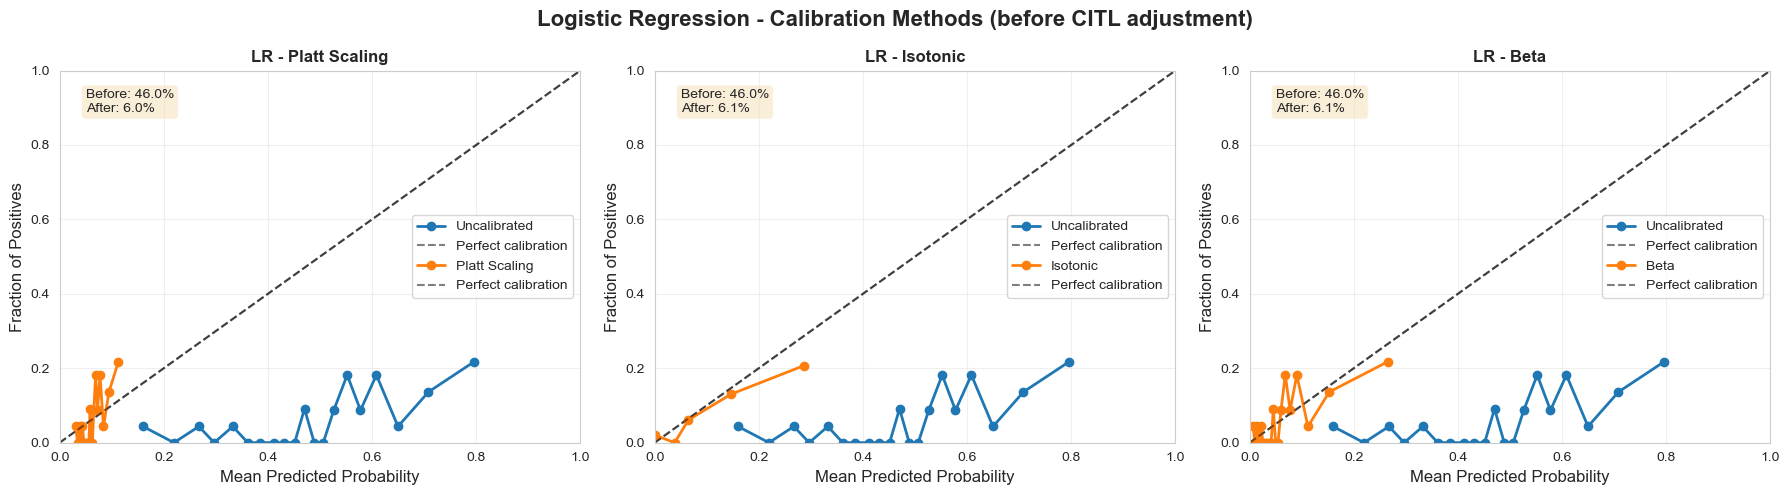


Note: These curves show calibration quality BEFORE the final
calibration-in-the-large adjustment to 4% PD target.


In [12]:
# Plot comparison for LR - BEFORE and AFTER calibration method (before CITL)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

methods_display = {'platt': 'Platt Scaling', 'isotonic': 'Isotonic', 'beta': 'Beta'}

for idx, (method, display_name) in enumerate(methods_display.items()):
    result = lr_calibration_results[method]
    
    # Plot uncalibrated (using 3 bins for stability with small validation set)
    plot_reliability_curve(y_val, result['uncalibrated_probas'], n_bins=20, 
                          ax=axes[idx], label='Uncalibrated')
    # Plot after calibration method but BEFORE calibration-in-the-large
    plot_reliability_curve(y_val, result['after_method_probas'], n_bins=20, 
                          ax=axes[idx], label=f'{display_name}')
    
    # Add text showing mean PD before and after method
    mean_before = result['uncalibrated_probas'].mean()
    mean_after_method = result['after_method_probas'].mean()
    
    axes[idx].text(0.05, 0.95, 
                  f'Before: {mean_before:.1%}\nAfter: {mean_after_method:.1%}',
                  transform=axes[idx].transAxes,
                  verticalalignment='top',
                  bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    axes[idx].set_title(f'LR - {display_name}', fontsize=12, fontweight='bold')
    axes[idx].legend()

plt.suptitle('Logistic Regression - Calibration Methods (before CITL adjustment)', 
            fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nNote: These curves show calibration quality BEFORE the final")
print("calibration-in-the-large adjustment to 4% PD target.")

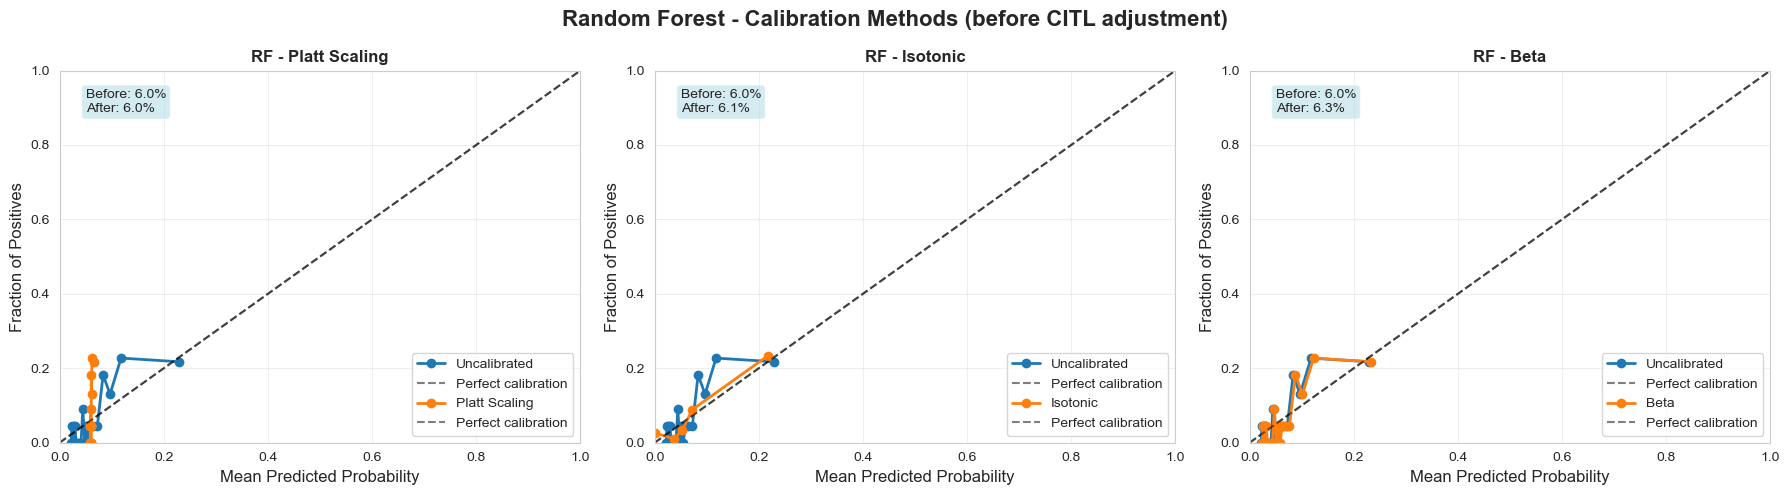


Note: These curves show calibration quality BEFORE the final
calibration-in-the-large adjustment to 4% PD target.


In [14]:
# Plot comparison for RF - BEFORE and AFTER calibration method (before CITL)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (method, display_name) in enumerate(methods_display.items()):
    result = rf_calibration_results[method]
    
    # Plot uncalibrated (using 3 bins for stability with small validation set)
    plot_reliability_curve(y_val, result['uncalibrated_probas'], n_bins=20, 
                          ax=axes[idx], label='Uncalibrated')
    # Plot after calibration method but BEFORE calibration-in-the-large
    plot_reliability_curve(y_val, result['after_method_probas'], n_bins=20, 
                          ax=axes[idx], label=f'{display_name}')
    
    # Add text showing mean PD before and after method
    mean_before = result['uncalibrated_probas'].mean()
    mean_after_method = result['after_method_probas'].mean()
    
    axes[idx].text(0.05, 0.95, 
                  f'Before: {mean_before:.1%}\nAfter: {mean_after_method:.1%}',
                  transform=axes[idx].transAxes,
                  verticalalignment='top',
                  bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
    
    axes[idx].set_title(f'RF - {display_name}', fontsize=12, fontweight='bold')
    axes[idx].legend()

plt.suptitle('Random Forest - Calibration Methods (before CITL adjustment)', 
            fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nNote: These curves show calibration quality BEFORE the final")
print("calibration-in-the-large adjustment to 4% PD target.")

## 8. Select Best Calibration Method and Save

In [ ]:
# Compare methods - choose based on ECE and Brier
print("\n" + "="*80)
print("CALIBRATION METHOD COMPARISON")
print("="*80)

comparison_data = []

for method in calibration_methods:
    # LR
    lr_wrapper = create_calibrated_model_pipeline(
        lr_model, 
        lr_calibration_results[method]['calibrator'],
        lr_calibration_results[method]['in_the_large']
    )
    lr_metrics = evaluate_model_comprehensive(lr_wrapper, X_val, y_val)
    
    # RF
    rf_wrapper = create_calibrated_model_pipeline(
        rf_model,
        rf_calibration_results[method]['calibrator'],
        rf_calibration_results[method]['in_the_large']
    )
    rf_metrics = evaluate_model_comprehensive(rf_wrapper, X_val, y_val)
    
    comparison_data.append({
        'Model': 'LR',
        'Method': method,
        'ECE': lr_metrics['ece'],
        'Brier': lr_metrics['brier_score'],
        'ROC-AUC': lr_metrics['roc_auc'],
        'Mean PD': lr_metrics['mean_predicted_probability'],
        'PD Gap': abs(lr_metrics['mean_predicted_probability'] - 0.04)
    })
    
    comparison_data.append({
        'Model': 'RF',
        'Method': method,
        'ECE': rf_metrics['ece'],
        'Brier': rf_metrics['brier_score'],
        'ROC-AUC': rf_metrics['roc_auc'],
        'Mean PD': rf_metrics['mean_predicted_probability'],
        'PD Gap': abs(rf_metrics['mean_predicted_probability'] - 0.04)
    })

comparison_df = pd.DataFrame(comparison_data)
print("\n", comparison_df.to_string(index=False))

# Select best method (lowest ECE + Brier combo)
best_lr_method = comparison_df[comparison_df['Model'] == 'LR'].sort_values('ECE').iloc[0]['Method']
best_rf_method = comparison_df[comparison_df['Model'] == 'RF'].sort_values('ECE').iloc[0]['Method']

print(f"\nRecommended calibration method for LR: {best_lr_method.upper()}")
print(f"Recommended calibration method for RF: {best_rf_method.upper()}")

In [ ]:
# Save calibrated models (using isotonic as default - usually performs best)
# You can change this based on the comparison above

best_method_lr = 'isotonic'  # Change if needed based on results
best_method_rf = 'isotonic'  # Change if needed based on results

# Create final calibrated models
lr_calibrated_final = create_calibrated_model_pipeline(
    lr_model,
    lr_calibration_results[best_method_lr]['calibrator'],
    lr_calibration_results[best_method_lr]['in_the_large']
)

rf_calibrated_final = create_calibrated_model_pipeline(
    rf_model,
    rf_calibration_results[best_method_rf]['calibrator'],
    rf_calibration_results[best_method_rf]['in_the_large']
)

# Save
save_model(lr_calibrated_final, '../models/lr_calibrated_4pct.pkl')
save_model(rf_calibrated_final, '../models/rf_calibrated_4pct.pkl')

print("\n" + "="*80)
print("CALIBRATED MODELS SAVED")
print("="*80)
print(f"\nLogistic Regression (calibrated with {best_method_lr}):")
print(f"  Saved to: ../models/lr_calibrated_4pct.pkl")
print(f"\nRandom Forest (calibrated with {best_method_rf}):")
print(f"  Saved to: ../models/rf_calibrated_4pct.pkl")

## 9. Final Evaluation Summary

In [ ]:
# Final comprehensive evaluation
print("\n" + "="*80)
print("FINAL CALIBRATED MODELS - COMPREHENSIVE EVALUATION")
print("="*80)

lr_final_metrics = evaluate_model_comprehensive(lr_calibrated_final, X_val, y_val)
rf_final_metrics = evaluate_model_comprehensive(rf_calibrated_final, X_val, y_val)

print_metrics_report(lr_final_metrics, "Logistic Regression (Calibrated to 4%)")
print("\n")
print_metrics_report(rf_final_metrics, "Random Forest (Calibrated to 4%)")

# Create summary comparison
summary = pd.DataFrame({
    'Metric': ['ROC-AUC', 'PR-AUC', 'KS', 'Brier', 'ECE', 'Mean PD', 'Actual Rate'],
    'LR (Calibrated)': [
        lr_final_metrics['roc_auc'],
        lr_final_metrics['pr_auc'],
        lr_final_metrics['ks_statistic'],
        lr_final_metrics['brier_score'],
        lr_final_metrics['ece'],
        lr_final_metrics['mean_predicted_probability'],
        lr_final_metrics['mean_actual_rate']
    ],
    'RF (Calibrated)': [
        rf_final_metrics['roc_auc'],
        rf_final_metrics['pr_auc'],
        rf_final_metrics['ks_statistic'],
        rf_final_metrics['brier_score'],
        rf_final_metrics['ece'],
        rf_final_metrics['mean_predicted_probability'],
        rf_final_metrics['mean_actual_rate']
    ]
})

print("\n" + "="*80)
print("SIDE-BY-SIDE COMPARISON")
print("="*80)
print(summary.to_string(index=False))
print("\n✅ Both models successfully calibrated to ~4% PD!")